# Spam Email Classification with Machine Learning

**Dataset:** [Spam Email Classification Dataset (Kaggle - purusinghvi)](https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset)

This dataset combines the **2007 TREC Public Spam Corpus** and the **Enron-Spam Dataset**, with 2 main columns:
- `text`: the email content
- `label`: `0` = not spam (ham), `1` = spam

**Goal:** Build and compare several Machine Learning models to classify emails as spam / not spam.

**Workflow:**
1. Load and explore the data (EDA)
2. Text preprocessing
3. Feature extraction with TF-IDF
4. Train multiple models: Naive Bayes, Logistic Regression, Linear SVM, Random Forest
5. Evaluate and compare the models
6. Save the best model and test it on new emails


## 0. Import libraries
`pip install pandas numpy scikit-learn matplotlib seaborn joblib`

In [ ]:
import os
import re
import string
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
DATA_PATH = "combined_data.csv"   
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Load the data

The `load_data()` function will:
- Automatically find the column containing email text (`text`, `message`, `email`, `body`, `content`...)
- Automatically find the label column (`label`, `spam`, `category`, `class`, `target`...)
- Normalize labels to `0`/`1` if they are strings (`spam`/`ham`)
- Drop rows with missing values or duplicates


In [2]:
def load_data(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File '{path}' not found. Please download the dataset from Kaggle "
            f"and place it in the same folder as this notebook (or edit DATA_PATH)."
        )

    df = pd.read_csv(path)
    cols_lower = {c.lower(): c for c in df.columns}

    text_col = None
    for cand in ["text", "message", "email", "body", "content"]:
        if cand in cols_lower:
            text_col = cols_lower[cand]
            break

    label_col = None
    for cand in ["label", "spam", "category", "class", "target"]:
        if cand in cols_lower:
            label_col = cols_lower[cand]
            break

    if text_col is None or label_col is None:
        raise ValueError(
            f"Could not identify text/label columns. Available columns: {list(df.columns)}."
        )

    df = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"})
    df = df.dropna(subset=["text", "label"]).drop_duplicates()

    if df["label"].dtype == object:
        df["label"] = (
            df["label"].str.strip().str.lower()
            .map({"spam": 1, "ham": 0, "1": 1, "0": 0})
        )
        df = df.dropna(subset=["label"])

    df["label"] = df["label"].astype(int)
    return df.reset_index(drop=True)


df = load_data(DATA_PATH)
print(f"Total emails: {len(df)}")
df.head()


Total emails: 83448


,text,label
0,ounce feather bowl hummingbird opec moment ala...,1
1,wulvob get your medircations online qnb ikud v...,1
2,computer connection from cnn com wednesday es...,0
3,university degree obtain a prosperous future m...,1
4,thanks for all your answers guys i know i shou...,0


### 1.1. Exploratory Data Analysis (EDA)

In [3]:
print("Label distribution:")
print(df["label"].value_counts().rename({0: "Not spam (0)", 1: "Spam (1)"}))
print()
print(f"Spam ratio: {df['label'].mean():.2%}")


Label distribution:
label
Spam (1)        43910
Not spam (0)    39538
Name: count, dtype: int64

Spam ratio: 52.62%


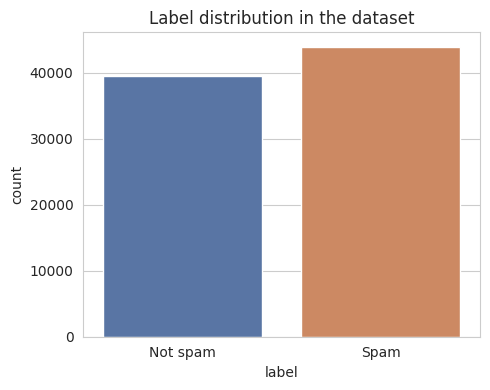

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df, palette=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Not spam", "Spam"])
plt.title("Label distribution in the dataset")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/label_distribution.png", dpi=150)
plt.show()


Look at the email length (number of characters) to better understand the data:

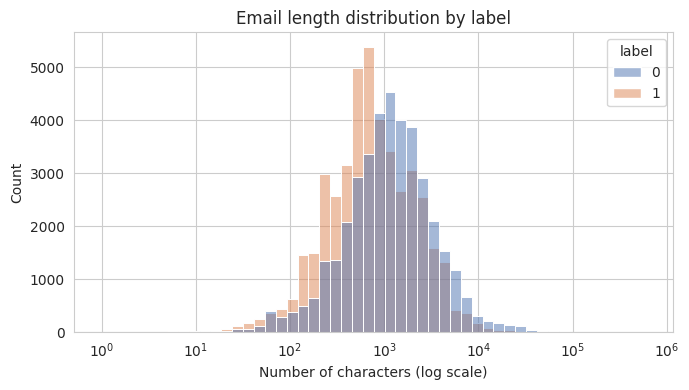

In [5]:
df["text_length"] = df["text"].astype(str).apply(len)

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="text_length", hue="label", bins=50, log_scale=(True, False),
             palette={0: "#4C72B0", 1: "#DD8452"})
plt.title("Email length distribution by label")
plt.xlabel("Number of characters (log scale)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/text_length_distribution.png", dpi=150)
plt.show()


## 2. Text preprocessing

Text cleaning steps:
- Lowercase the text
- Remove URLs
- Remove HTML tags
- Remove punctuation and non-alphabetic characters
- Normalize whitespace


In [6]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = NON_ALPHA_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text


df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Before cleaning:")
print(df["text"].iloc[0][:200], "...\n")
print("After cleaning:")
print(df["clean_text"].iloc[0][:200], "...")


Before cleaning:
ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage ...

After cleaning:
ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage ...


## 3. Train/test split & TF-IDF feature extraction

- Split the data: 80% train / 20% test, preserving the label ratio (`stratify`).
- Use **TF-IDF** (Term Frequency – Inverse Document Frequency) to turn text into numeric vectors, using unigrams + bigrams, with a maximum of 20,000 features.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"] # Keep class ratio balanced
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Train: 66741 | Test: 16686


In [8]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"TF-IDF feature dimensions: {X_train_vec.shape[1]}")


TF-IDF feature dimensions: 20000


## 4. Train & compare multiple models

We train 4 models commonly used for text classification:

| Model | Characteristics |
|---|---|
| **Naive Bayes** | Fast, works very well with count/frequency-based text data |
| **Logistic Regression** | Linear model, easy to interpret, stable |
| **Linear SVM** | Usually achieves very high accuracy on high-dimensional data like TF-IDF |
| **Random Forest** | Ensemble model, can capture non-linear relationships |

> `LinearSVC` doesn't support `predict_proba` by default, so we wrap it with `CalibratedClassifierCV` to get probability estimates for the AUC/ROC evaluation.


In [9]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
trained_models = {}
roc_data = {}


### 4.1. Training + evaluation loop for each model

In [10]:
for name, model in models.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    y_proba = model.predict_proba(X_test_vec)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(classification_report(y_test, y_pred, target_names=["Not spam", "Spam"]))
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1": f1, "AUC": auc})
    trained_models[name] = model
    roc_data[name] = roc_curve(y_test, y_proba)



Training: Naive Bayes


              precision    recall  f1-score   support

    Not spam       0.96      0.98      0.97      7907
        Spam       0.98      0.96      0.97      8779

    accuracy                           0.97     16686
   macro avg       0.97      0.97      0.97     16686
weighted avg       0.97      0.97      0.97     16686

Accuracy=0.9712  Precision=0.9802  Recall=0.9647  F1=0.9724  AUC=0.9965

Training: Logistic Regression


              precision    recall  f1-score   support

    Not spam       0.99      0.97      0.98      7907
        Spam       0.98      0.99      0.98      8779

    accuracy                           0.98     16686
   macro avg       0.98      0.98      0.98     16686
weighted avg       0.98      0.98      0.98     16686

Accuracy=0.9830  Precision=0.9776  Recall=0.9904  F1=0.9840  AUC=0.9980

Training: Random Forest


              precision    recall  f1-score   support

    Not spam       0.99      0.98      0.98      7907
        Spam       0.98      0.99      0.98      8779

    accuracy                           0.98     16686
   macro avg       0.98      0.98      0.98     16686
weighted avg       0.98      0.98      0.98     16686

Accuracy=0.9834  Precision=0.9799  Recall=0.9887  F1=0.9843  AUC=0.9977


### 4.2. Confusion matrix for each model

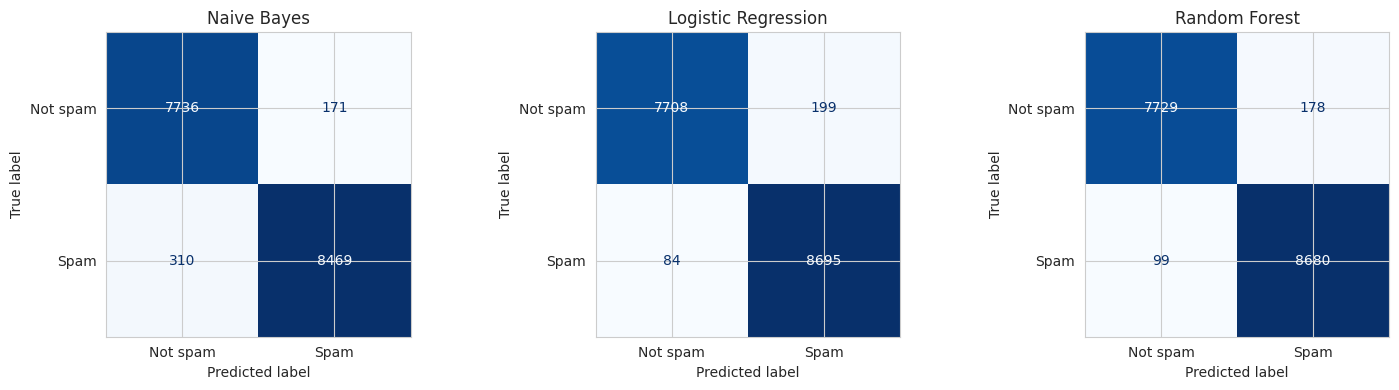

In [11]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_vec)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not spam", "Spam"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150)
plt.show()


### 4.3. Visual walkthrough: a simple Decision Tree (explaining Gini)

Random Forest is made up of 200 individual trees, so it can't be plotted directly and would be hard to read anyway (the data has 20,000 TF-IDF dimensions).

To make it easier to see **how the model uses Gini to make decisions**, we train a separate **shallow decision tree** (`max_depth=4`, only 4 levels deep) on the same TF-IDF data. This tree isn't the best-performing model (its accuracy is lower than Random Forest), but it lets us clearly see:
- Which words/tokens are used to split spam vs. not-spam emails at each step
- How the Gini index decreases as we go from the root down to the leaves


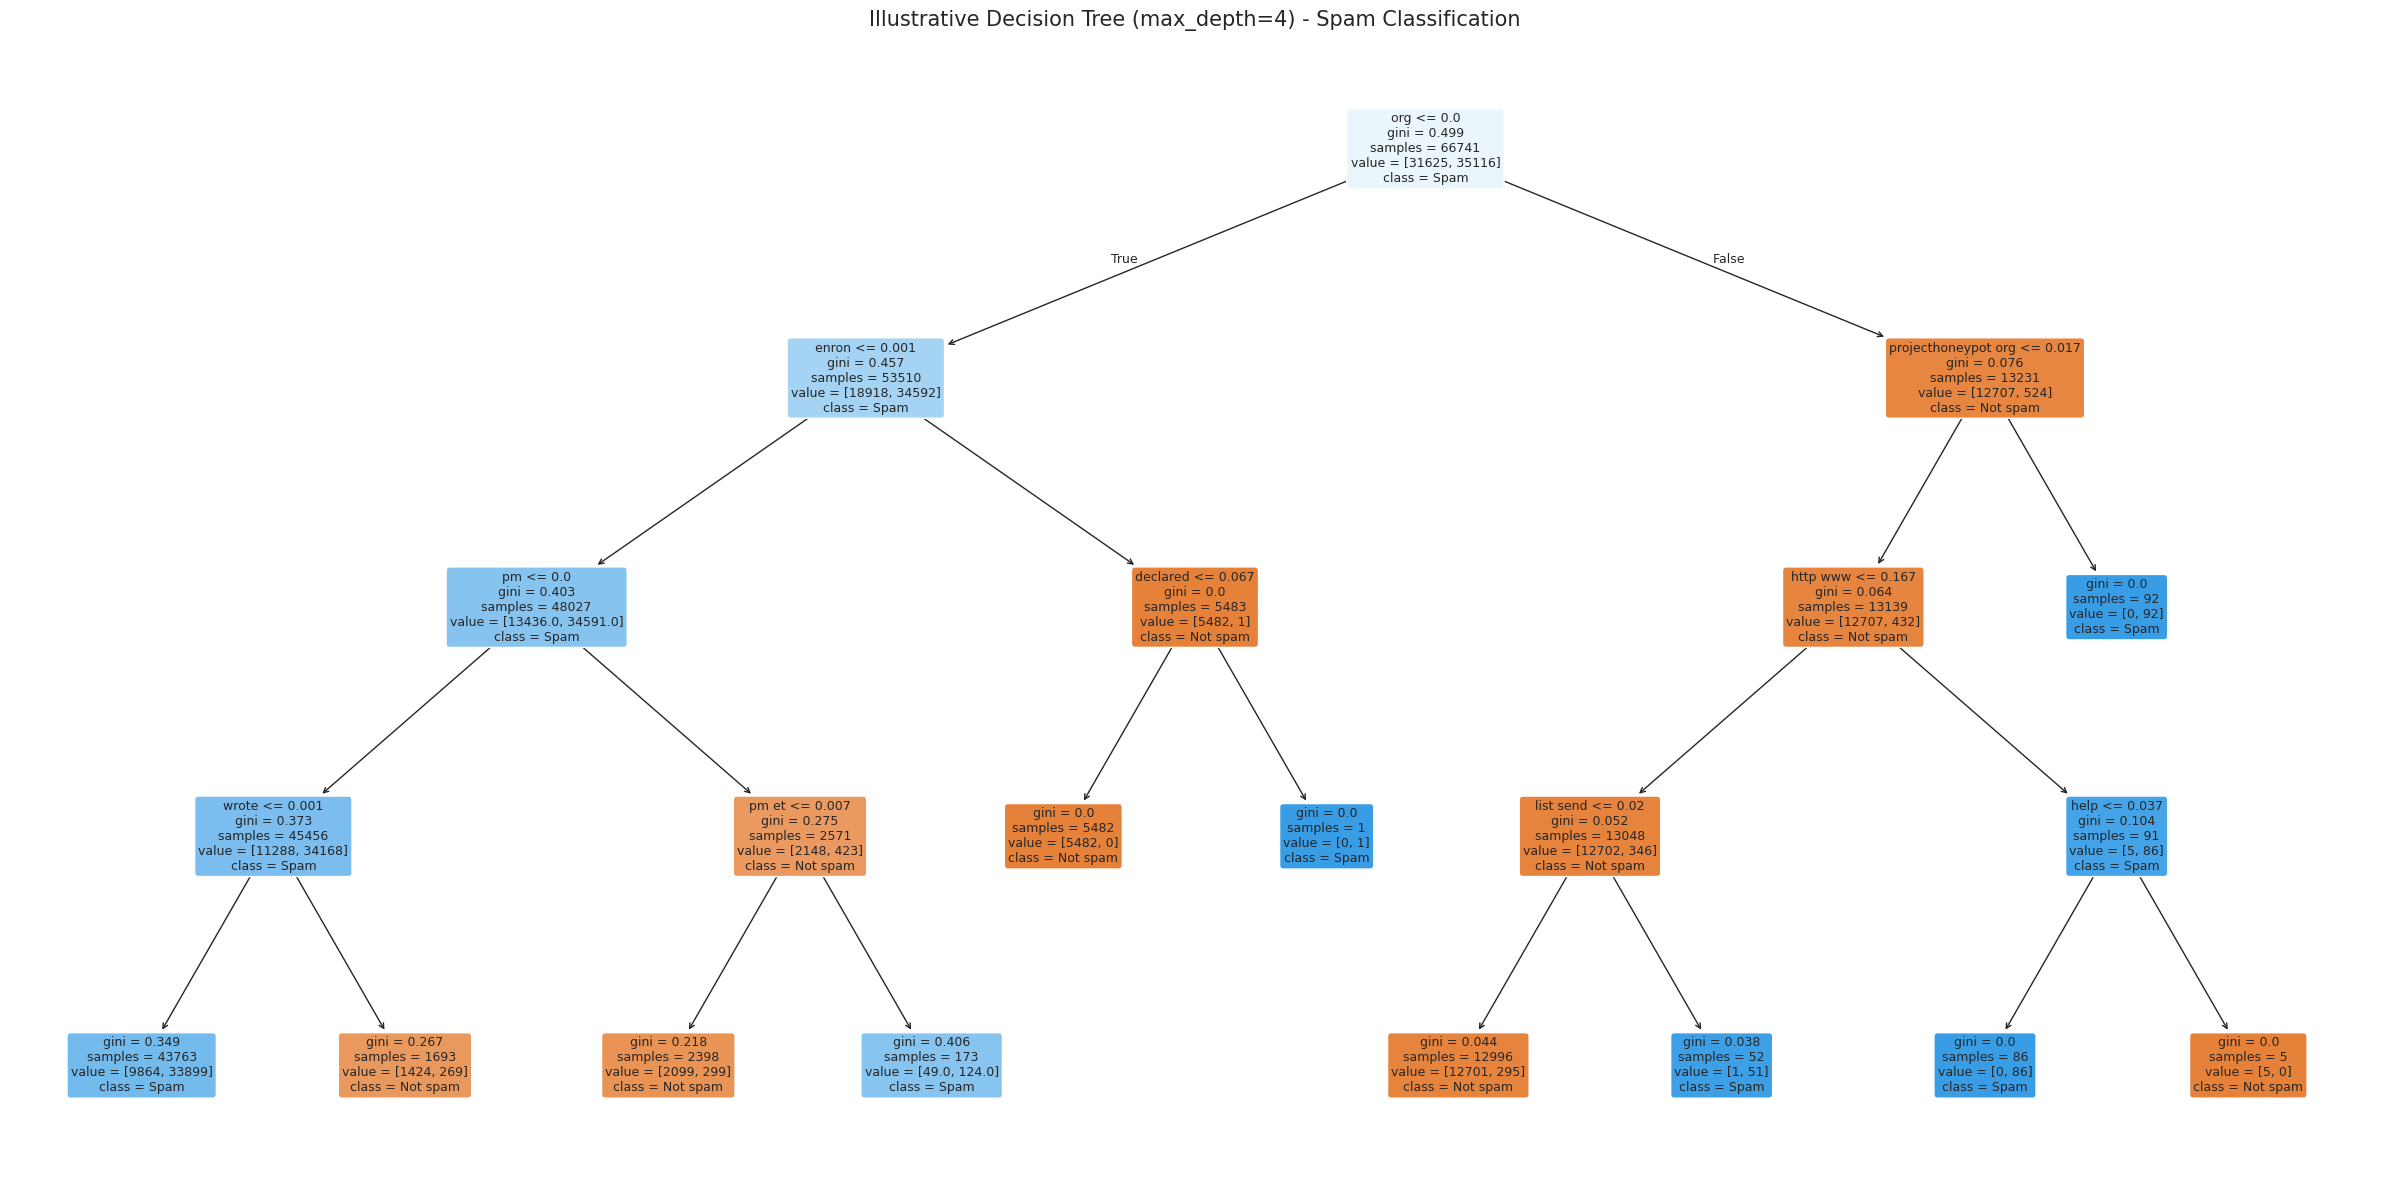

Not spam ratio = 0.4738 | Spam ratio = 0.5262
Manually computed root Gini = 0.4986  (should match the gini shown at the top node)


In [ ]:
tree_viz = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree_viz.fit(X_train_vec, y_train)

feature_names_tfidf = vectorizer.get_feature_names_out()
class_names = ["Not spam", "Spam"]

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    tree_viz,
    feature_names=feature_names_tfidf,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
plt.title("Illustrative Decision Tree (max_depth=4) - Spam Classification", fontsize=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spam_decision_tree.png", dpi=150)
plt.show()

# Verify the Gini formula at the root node
p_ham = (y_train == 0).mean()
p_spam = (y_train == 1).mean()
gini_root = 1 - (p_ham**2 + p_spam**2)
print(f"Not spam ratio = {p_ham:.4f} | Spam ratio = {p_spam:.4f}")
print(f"Manually computed root Gini = {gini_root:.4f}  (should match the gini shown at the top node)")


### 4.4. Which words matter most? (Feature Importance from Random Forest)

Extract `feature_importances_` from the **Random Forest** model (the model with the highest F1-score) to see the top 15 words/tokens that most influence the spam classification.

,feature,importance
5441,enron,0.022678
19755,wrote,0.018231
17832,thanks,0.011656
1047,attached,0.011643
13503,pm,0.011627
12676,org,0.010230
17229,subject,0.009792
19039,vince,0.008944
13195,perl,0.007381
2270,cc,0.007322


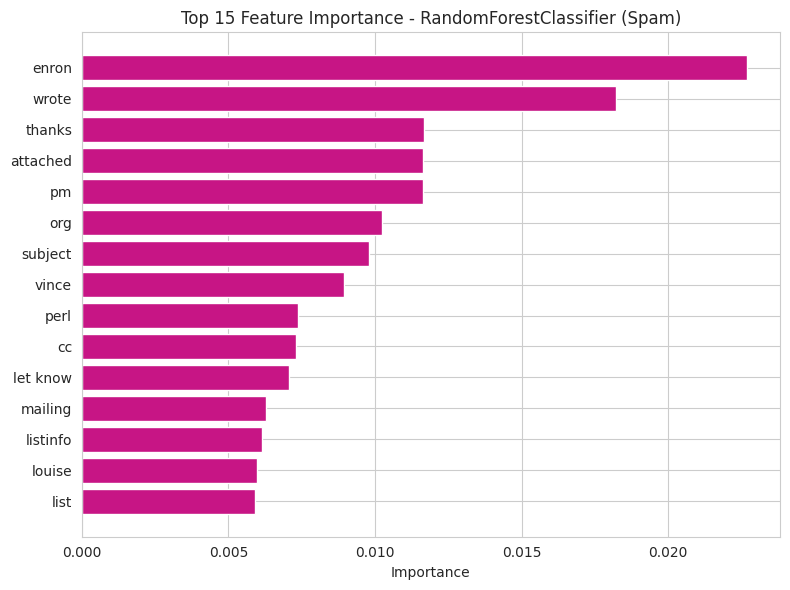

In [13]:
rf_model = trained_models["Random Forest"]
rf_importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": feature_names_tfidf,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

display(feat_imp_df.head(15))

top15 = feat_imp_df.head(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["feature"], top15["importance"], color="mediumvioletred")
ax.set_xlabel("Importance")
ax.set_title("Top 15 Feature Importance - RandomForestClassifier (Spam)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spam_feature_importance.png", dpi=150)
plt.show()


## 5. Comparison table & visualizations

In [14]:
results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False)
results_df


,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.983399,0.979905,0.988723,0.984294,0.997676
1,Logistic Regression,0.983040,0.977625,0.990432,0.983987,0.997950
2,Naive Bayes,0.971173,0.980208,0.964688,0.972386,0.996500


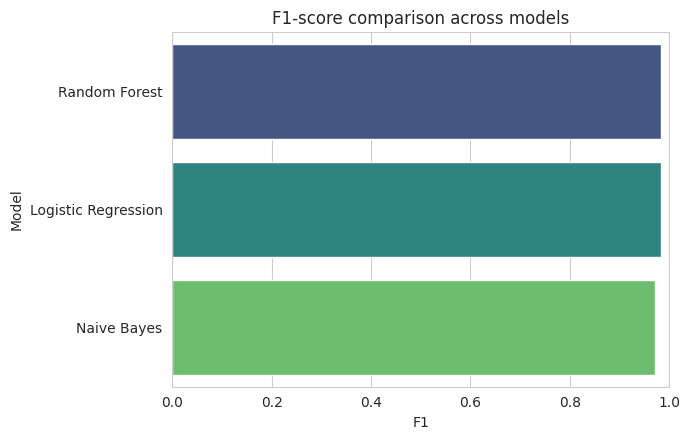

In [15]:
plt.figure(figsize=(7, 4.5))
sns.barplot(x="F1", y="Model", data=results_df, palette="viridis")
plt.title("F1-score comparison across models")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_f1_comparison.png", dpi=150)
plt.show()


### 5.1. ROC Curves

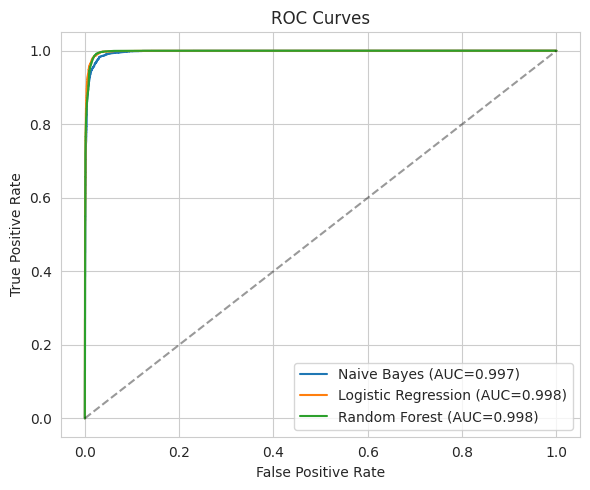

In [16]:
plt.figure(figsize=(6, 5))
for name, (fpr, tpr, _) in roc_data.items():
    auc_val = results_df.loc[results_df["Model"] == name, "AUC"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves.png", dpi=150)
plt.show()


## 6. Save the best model

The model with the **highest F1-score** is selected and saved (along with the TF-IDF vectorizer) for later use.


In [17]:
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
print(f"🏆 Best model: {best_name}")
print(results_df.iloc[0])

joblib.dump(best_model, f"{OUTPUT_DIR}/best_model.joblib")
joblib.dump(vectorizer, f"{OUTPUT_DIR}/tfidf_vectorizer.joblib")
print(f"\nSaved to: {OUTPUT_DIR}/best_model.joblib and {OUTPUT_DIR}/tfidf_vectorizer.joblib")


🏆 Best model: Random Forest
Model        Random Forest
Accuracy          0.983399
Precision         0.979905
Recall            0.988723
F1                0.984294
AUC               0.997676
Name: 0, dtype: object



Saved to: output/best_model.joblib and output/tfidf_vectorizer.joblib


## 7. Try predicting on new emails

The `predict_new_email()` function loads the saved model + vectorizer, cleans the input text, and returns a spam / not spam prediction with a probability score.


In [18]:
def predict_new_email(text: str,
                       model_path=f"{OUTPUT_DIR}/best_model.joblib",
                       vectorizer_path=f"{OUTPUT_DIR}/tfidf_vectorizer.joblib"):
    model = joblib.load(model_path)
    vec = joblib.load(vectorizer_path)
    cleaned = clean_text(text)
    X = vec.transform([cleaned])
    pred = model.predict(X)[0]
    proba = model.predict_proba(X)[0][1]
    label = "SPAM 🚫" if pred == 1 else "NOT SPAM ✅"
    print(f"Prediction: {label}  (spam probability: {proba:.2%})")
    return pred, proba


# Example:
predict_new_email("Congratulations! You have won a free iPhone. Click here now to claim your prize!!!")


Prediction: SPAM 🚫  (spam probability: 57.00%)


(np.int64(1), np.float64(0.57))

In [19]:
predict_new_email("Hi John, please find attached the quarterly report we discussed in yesterday's meeting.")


Prediction: NOT SPAM ✅  (spam probability: 7.42%)


(np.int64(0), np.float64(0.07423357664233576))